In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

In [2]:
# Import dataset
dataset = pd.read_csv("data/houses_to_rent.csv")
dataset.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,rent amount
0,1,240,3,3,4,0,acept,furnished,8000
1,0,64,2,1,1,10,acept,not furnished,820
2,1,443,5,5,4,3,acept,furnished,7000
3,1,73,2,2,1,12,acept,not furnished,1250
4,1,19,1,1,0,0,not acept,not furnished,1200


In [4]:
# Transform strings into dummy
dataset[["animal", "furniture"]] = pd.get_dummies(dataset[["animal", "furniture"]],
                                                  drop_first = True)
dataset.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,rent amount
0,1,240,3,3,4,0,False,False,8000
1,0,64,2,1,1,10,False,True,820
2,1,443,5,5,4,3,False,False,7000
3,1,73,2,2,1,12,False,True,1250
4,1,19,1,1,0,0,True,True,1200


# Correlation Matrix

In [5]:
# Isolate X
X = dataset.drop(columns = 'rent amount')
X.head(1)

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture
0,1,240,3,3,4,0,False,False


<Axes: >

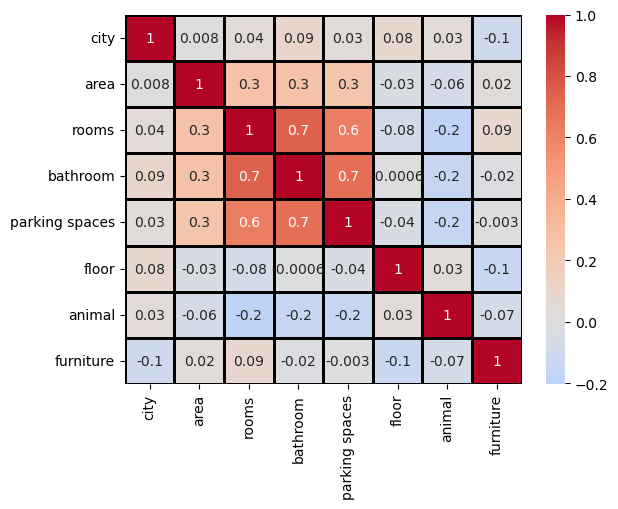

In [6]:
# Correlation Matrix
import seaborn as sns
sns.heatmap(X.corr(),
            annot = True,
            fmt = '.1g',
            center = 0,
            cmap = 'coolwarm',
            linewidths = 1,
            linecolor = 'black')

In [7]:
# Standardization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns = X.columns)
X_scaled.head()

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture
0,1.0,0.009351,0.222222,0.222222,0.333333,0.000000,0.0,0.0
1,0.0,0.002195,0.111111,0.000000,0.083333,0.101010,0.0,1.0
2,1.0,0.017604,0.444444,0.444444,0.333333,0.030303,0.0,0.0
3,1.0,0.002561,0.111111,0.111111,0.083333,0.121212,0.0,1.0
4,1.0,0.000366,0.000000,0.000000,0.000000,0.000000,1.0,1.0


# Principal Component Analysis

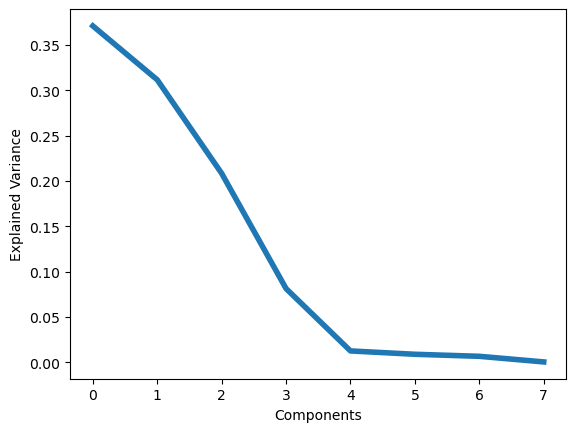

In [8]:
# Optimal number of components
model = PCA(random_state=1502).fit(X_scaled)
plt.plot(model.explained_variance_ratio_,
         linewidth = 4)
plt.xlabel('Components')
plt.ylabel('Explained Variance')
plt.show()

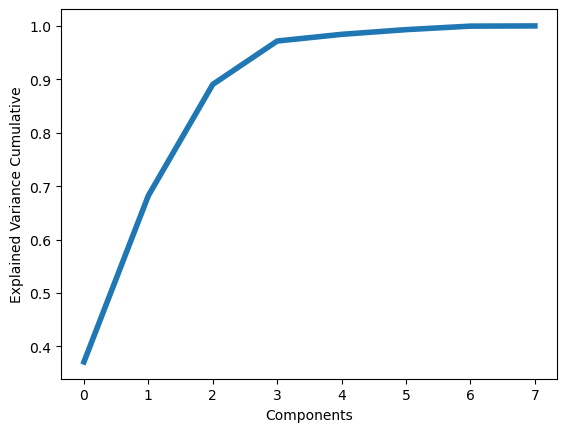

In [9]:
# Cumulative
plt.plot(np.cumsum(model.explained_variance_ratio_),
         linewidth = 4)
plt.xlabel('Components')
plt.ylabel('Explained Variance Cumulative')
plt.show()

In [10]:
# PCA
model = PCA(n_components=4,
            random_state = 1502).fit(X_scaled)

In [11]:
# Interpretation 
model_interpretation = pd.DataFrame(model.components_,
                                    columns = X.columns)
model_interpretation

,city,area,rooms,bathroom,parking spaces,floor,animal,furniture
0,-0.181418,0.001894,0.052840,0.026016,0.028430,-0.020501,-0.513750,0.835731
1,-0.087693,-0.002332,-0.055603,-0.079433,-0.064195,-0.008521,0.847689,0.510033
2,0.976331,0.001294,0.038218,0.062905,0.028570,0.006666,-0.009316,0.201026
3,-0.075883,0.020620,0.487555,0.685306,0.518733,-0.011778,0.131167,-0.005982


In [12]:
# Components
components = model.transform(X_scaled)
components = pd.DataFrame(components,
                          columns = ['city characteristics',
                                     'accepts animals and has furniture',
                                     'rural small place',
                                     'fantastic houses'])
components.head()

,city characteristics,accepts animals and has furniture,rural small place,fantastic houses
0,-0.512212,-0.606922,-0.001389,0.138911
1,0.484093,0.029839,-0.801398,-0.128672
2,-0.495294,-0.637207,0.021295,0.399360
3,0.305152,-0.066853,0.182058,-0.128640
4,-0.217248,0.802227,0.158314,-0.169636


In [13]:
# Merge the dataset
final_dataset = pd.concat([components, dataset], axis = 1)
final_dataset.head()

,city characteristics,accepts animals and has furniture,rural small place,fantastic houses,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,rent amount
0,-0.512212,-0.606922,-0.001389,0.138911,1,240,3,3,4,0,False,False,8000
1,0.484093,0.029839,-0.801398,-0.128672,0,64,2,1,1,10,False,True,820
2,-0.495294,-0.637207,0.021295,0.399360,1,443,5,5,4,3,False,False,7000
3,0.305152,-0.066853,0.182058,-0.128640,1,73,2,2,1,12,False,True,1250
4,-0.217248,0.802227,0.158314,-0.169636,1,19,1,1,0,0,True,True,1200


In [14]:
# t-SNE
from sklearn.manifold import TSNE
model = TSNE(n_components = 2,
             random_state = 1503)
components = model.fit_transform(X)
components

array([[ 42.553974 , -56.85287  ],
       [-38.56414  ,   7.0594635],
       [ 74.910706 ,  -1.908284 ],
       ...,
       [-54.37042  , -15.90342  ],
       [ 40.7655   ,  54.675076 ],
       [-22.780857 , -32.569843 ]], dtype=float32)

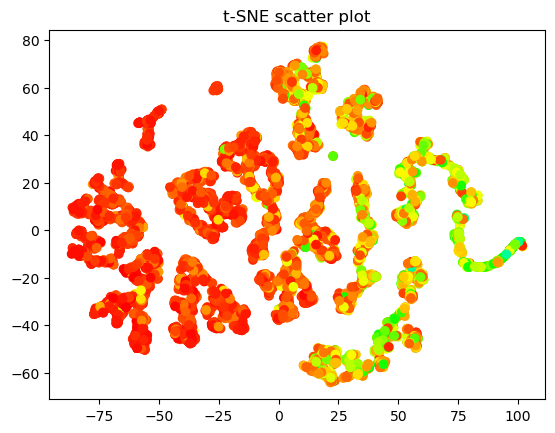

In [15]:
# Plotting
plt.scatter(components[:,0],
            components[:,1],
            cmap = "hsv",
            c = dataset["rent amount"])
plt.title("t-SNE scatter plot")
plt.show()

In [16]:
# Load the data
data = pd.read_csv('data/abalone-challenge.csv')
data.head()

,Sex,Lenght,Diameter,Height,Whole weight,Shucked Weight,Viscera Weight,Shell Weight,Rings (+1.5=Years)
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [17]:
# Transform gender variable
data = pd.get_dummies(data, drop_first=True)
data.head()

,Lenght,Diameter,Height,Whole weight,Shucked Weight,Viscera Weight,Shell Weight,Rings (+1.5=Years),Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,True,False


In [18]:
# Isolate X
X = data.drop(columns = 'Rings (+1.5=Years)')
X.head(1)

,Lenght,Diameter,Height,Whole weight,Shucked Weight,Viscera Weight,Shell Weight,Sex_I,Sex_M
0,0.455,0.365,0.095,0.514,0.2245,0.101,0.15,False,True


<Axes: >

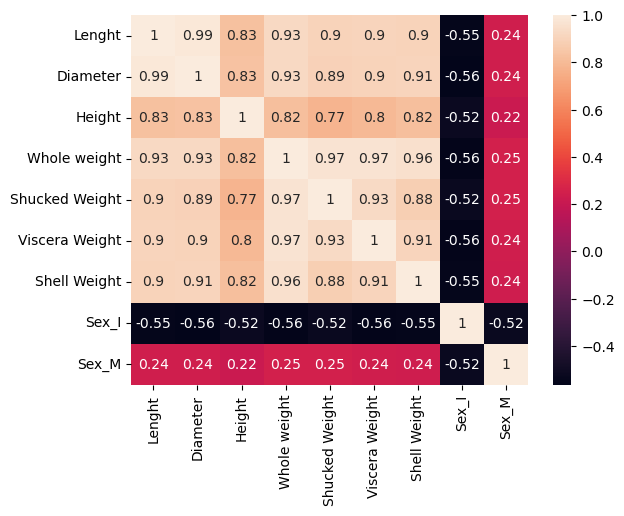

In [19]:
# Correlation Matrix
import seaborn as sns
sns.heatmap(X.corr(),
            annot = True)

In [21]:
# Standardization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X))
X_scaled.head()

,0,1,2,3,4,5,6,7,8
0,0.513514,0.521008,0.084071,0.181335,0.150303,0.132324,0.147982,0.0,1.0
1,0.371622,0.352941,0.079646,0.079157,0.066241,0.063199,0.068261,0.0,1.0
2,0.614865,0.613445,0.119469,0.239065,0.171822,0.185648,0.207773,0.0,0.0
3,0.493243,0.521008,0.110619,0.182044,0.144250,0.149440,0.152965,0.0,1.0
4,0.344595,0.336134,0.070796,0.071897,0.059516,0.051350,0.053313,1.0,0.0


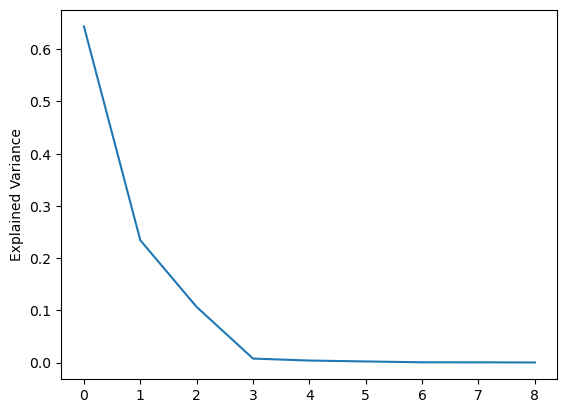

In [22]:
# Determine optimal number of components
model = PCA(random_state=1502).fit(X_scaled)
plt.plot(model.explained_variance_ratio_)
plt.ylabel('Explained Variance')
plt.show()

In [23]:
# PCA
model = PCA(n_components=3,
            random_state = 1502).fit(X_scaled)

In [24]:
# Interpretation
interpretation = pd.DataFrame(model.components_,
                              columns = X.columns)
interpretation

,Lenght,Diameter,Height,Whole weight,Shucked Weight,Viscera Weight,Shell Weight,Sex_I,Sex_M
0,-0.162097,-0.168853,-0.033600,-0.177639,-0.146710,-0.145040,-0.137066,0.673094,-0.630973
1,-0.254843,-0.262763,-0.051207,-0.271986,-0.221049,-0.223921,-0.213838,0.340180,0.727296
2,0.294654,0.293744,0.052035,0.329658,0.292162,0.257841,0.245421,0.656281,0.269694


In [25]:
# t-sNE
from sklearn.manifold import TSNE
model = TSNE(n_components = 2,
             random_state = 1502)
components = model.fit_transform(X)

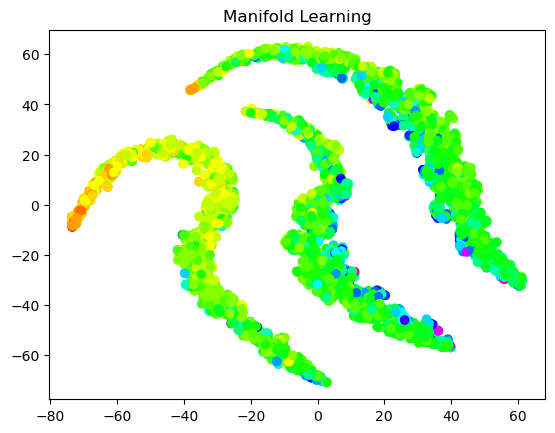

In [26]:
# Plotting
plt.scatter(components[:,0],
            components[:,1],
            cmap = "hsv",
            c = data["Rings (+1.5=Years)"])
plt.title("Manifold Learning")
plt.show()